# Error bands on the GLIMMER fixed-weight forecaster

Stage 1 of this project (the notebooks in `notebooks/`) asked how accurate different glucose forecasters are. This notebook starts stage 2 and asks a different question about one of them: when the model says glucose will be 150 mg/dL in an hour, how wrong could that be, and can we draw an honest band around that prediction?

The model here is the **fixed-weight model** from the GLIMMER paper, a CNN-LSTM trained to care more about dangerous highs and lows (hypo errors weighted 3.29 times, hyper errors 2.38 times, everything else 1 time). These are the `cnn_lstm_v1` checkpoints from stage 1, run on all 25 AZT1D patients. Nothing is retrained. Every number below comes from bands built on top of that model's saved predictions.

Three ways of building the bands are compared, each borrowed from a different field:

- **Conformal (basic).** Look at how wrong the model was on data it was not trained on, find the error size that covers 80% (or 95%) of those cases, and use that as a fixed plus-or-minus around every prediction. It works for any model and is the simplest of the three, so it is the reference point. Its weakness is that the band is the same width whether things are calm or chaotic.
- **GARCH (finance).** Built to track volatility. It watches how big the model's recent errors have been and widens the band when errors have been large, narrows it when they have been small. The catch is that a 60-minute forecast's error is only known 60 minutes later, so it can only learn from errors that have already had time to play out.
- **Analog Ensemble (weather).** Find the 50 past moments that looked most like right now (similar last two hours of glucose, insulin, and carbs, at a similar time of day), look at how wrong the model was in each of those moments, and add that spread of errors to today's prediction. This band can lean to one side, since the model tends to be wrong in a particular direction in a particular situation.

Every method is fitted only on each patient's **validation period** (data the model did not train on, but that comes before the test period), and judged on the **test period**, which nothing was fitted on. Two band sizes are shown: 80% (should contain the real glucose 8 times out of 10) and 95%.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks_2" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from azt1d import loading, plotting
from azt1d import reference as ref
from azt1d.glimmer import checkpoint as ckpt
from azt1d.glimmer import uncertainty as unc
from azt1d.glimmer.clinical import clarke_error_grid_zones, clarke_zone_percentages, draw_clarke_grid

plotting.apply_style()
pd.set_option("display.max_columns", None)

LEVELS = (0.8, 0.95)
METHODS = unc.METHODS
METHOD_COLOR = dict(zip(METHODS, plotting.CATEGORICAL[:3]))
CKPT_DIR = PROJECT_ROOT / "data" / "processed" / "checkpoints" / "cnn_lstm_v1"

## 1. Rebuild the forecasts

The checkpoints only saved each patient's test predictions. The methods need validation-period predictions too, so both are rebuilt here from the saved model weights. Before trusting anything else, the rebuilt test predictions are compared to the ones saved at training time. They should match exactly.

In [2]:
df = loading.load_real_dataset(PROJECT_ROOT / "data" / "raw", PROJECT_ROOT / "data" / "processed")
subject_ids = sorted(int(s) for s in df["subject_id"].unique())

frames, results, gaps = {}, {}, {}
for sid in subject_ids:
    res = ckpt.load_result(CKPT_DIR, sid)
    df_subject = df[df["subject_id"] == sid].reset_index(drop=True)
    val, test = unc.forecast_frames(res, df_subject)
    frames[sid], results[sid] = (val, test), res
    gaps[sid] = unc.matches_stored_predictions(test, res)

print(f"Rebuilt forecasts for {len(frames)} patients.")
print(f"Largest gap between rebuilt and originally saved test predictions: {max(gaps.values()):.6f} mg/dL")
print(f"Validation windows per patient: {min(len(f[0].pred) for f in frames.values())} to {max(len(f[0].pred) for f in frames.values())}")
print(f"Test windows per patient:       {min(len(f[1].pred) for f in frames.values())} to {max(len(f[1].pred) for f in frames.values())}")

Rebuilt forecasts for 25 patients.
Largest gap between rebuilt and originally saved test predictions: 0.000000 mg/dL
Validation windows per patient: 1281 to 2198
Test windows per patient:       1601 to 2747


## 2. Checks that the setup is honest

Three things that would quietly ruin the comparison if they were wrong, tested directly rather than assumed.

In [3]:
# 1. Rebuilt predictions match what was saved at training time.
assert max(gaps.values()) < 0.05, "rebuilt predictions do not match the checkpoints"

# 2. GARCH never peeks. Changing residuals that had not happened yet (target time after the
#    moment the forecast was issued) must not change the variance used for that forecast.
val1, test1 = frames[1]
params = unc.fit_garch(val1.resid)
e = np.concatenate([val1.resid, test1.resid])[:300]
e_changed = e.copy()
e_changed[150:] += 1000.0  # pretend everything from step 150 on was wildly different
init_var = float(np.var(val1.resid - params.mu))  # from calibration data only
v_a = unc.garch_h_step_variance(e, params, init_var)
v_b = unc.garch_h_step_variance(e_changed, params, init_var)
lag = unc.LAG
assert np.allclose(v_a[lag:150 + lag], v_b[lag:150 + lag]), "GARCH variance changed because of a future residual"
assert not np.allclose(v_a[150 + lag:], v_b[150 + lag:]), "changed residuals should matter once they are actually known"

# 3. Conformal quantile matches a hand calculation: residual sizes 1..100, 90% band.
#    ceil(101 * 0.9) = 91, so the half width should be exactly 91.
assert unc.conformal_halfwidth(np.arange(1, 101, dtype=float), alpha=0.1) == 91.0

# 4. The analog pool only ever contains earlier (validation) data, and chosen analogs are spread out.
for sid, (v, t) in frames.items():
    assert v.target_time.max() < t.target_time.min(), "calibration period overlaps the test period"
rng = np.random.default_rng(0)
picked = unc.select_analogs(rng.random(1735), k=50, min_gap=12, pool_cap=600)
assert len(picked) == 50 and np.diff(np.sort(picked)).min() >= 12

print("All checks passed.")

All checks passed.


## 3. Build the bands for all 25 patients

In [4]:
bands = {sid: unc.build_bands(frames[sid][0], frames[sid][1], LEVELS) for sid in subject_ids}

# GARCH parameters, out of curiosity: alpha is how strongly a big error today widens the next band,
# beta is how long that widening lingers.
garch_rows = []
for sid in subject_ids:
    p = unc.fit_garch(frames[sid][0].resid)
    garch_rows.append({"subject": sid, "alpha": p.alpha, "beta": p.beta, "alpha_plus_beta": p.alpha + p.beta})
pd.DataFrame(garch_rows).set_index("subject").describe().loc[["mean", "min", "max"]].round(3)

,alpha,beta,alpha_plus_beta
mean,0.896,0.088,0.984
min,0.721,0.000,0.903
max,1.000,0.279,1.000


## 4. What the bands look like against real glucose

Each figure is a 2-day stretch of one patient's held-out test data, centered on that patient's lowest real glucose reading (the moment that matters most for safety). The black line is real glucose, the colored line is the model's 60-minute-ahead prediction, and the shaded bands are the 80% (darker) and 95% (lighter) bands. The dashed lines mark 70 (low) and 180 (high) mg/dL.

Subject 1 is the project's usual example. The best and worst patients are picked automatically from the fixed-weight model's own test error.

Subjects shown: 1 (usual example), 16 (best, RMSE 33.1), 21 (worst, RMSE 54.9)


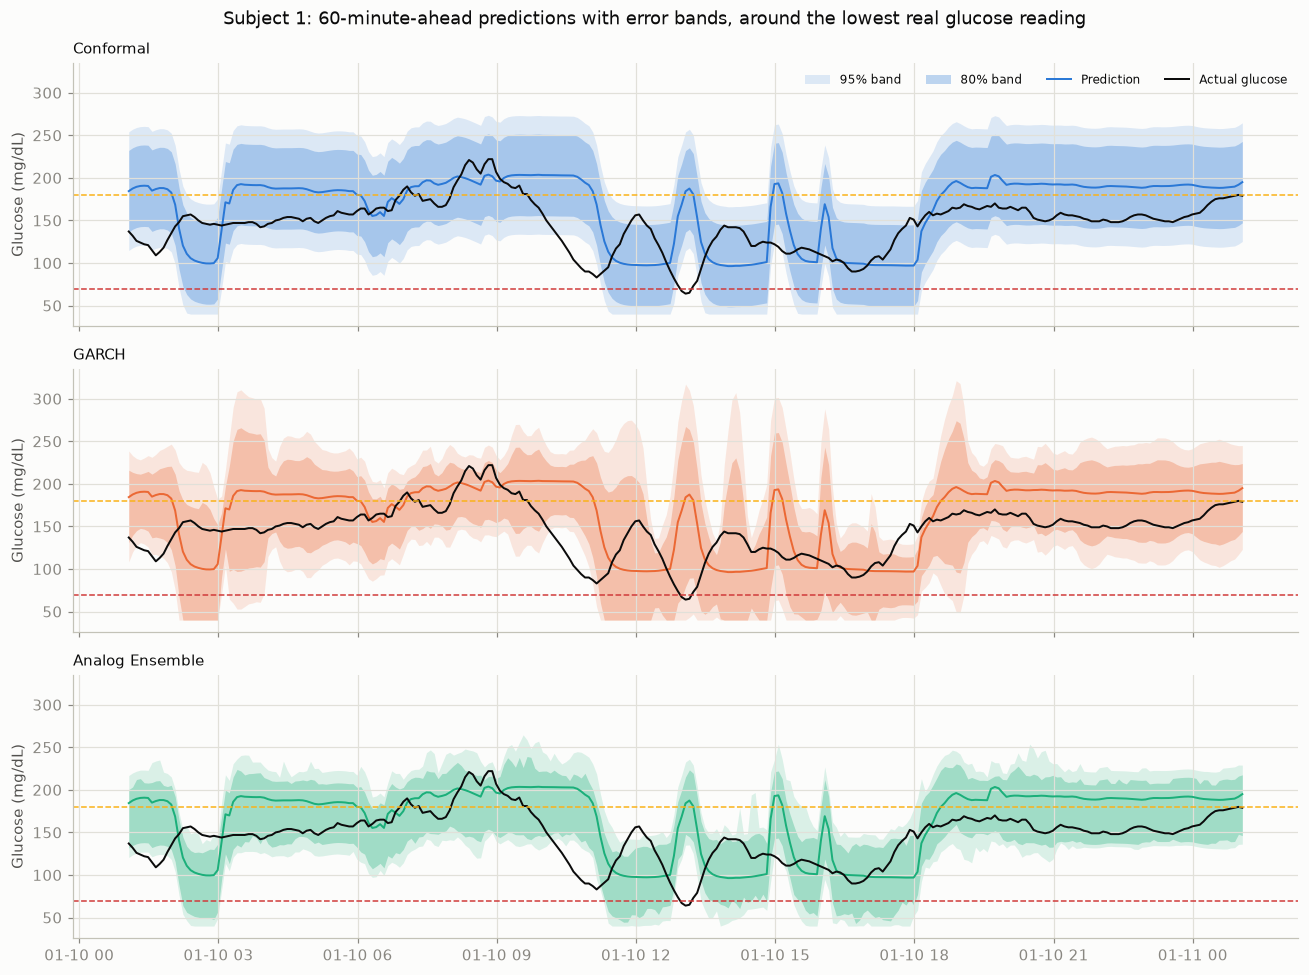

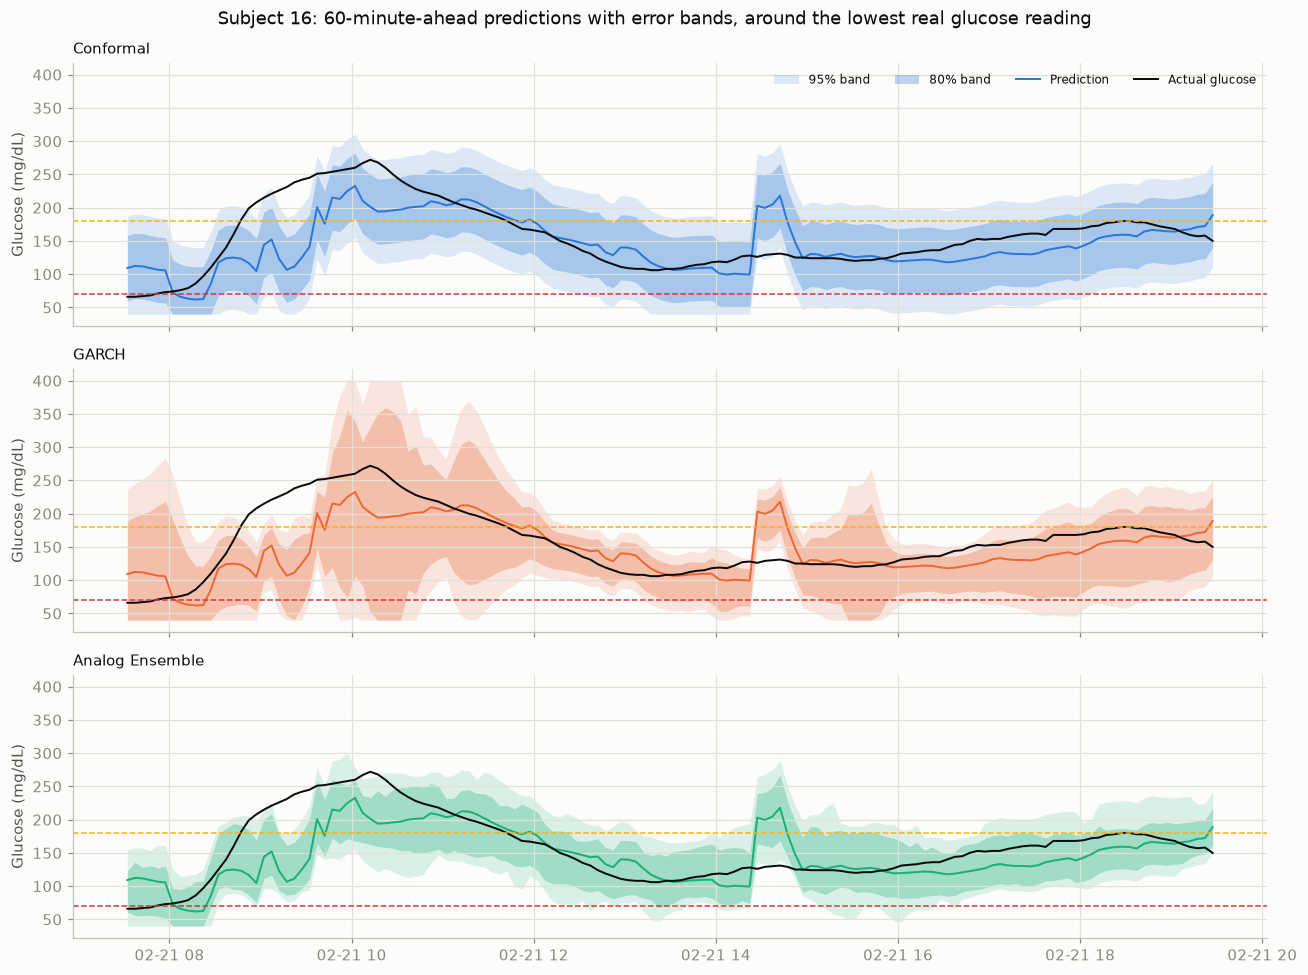

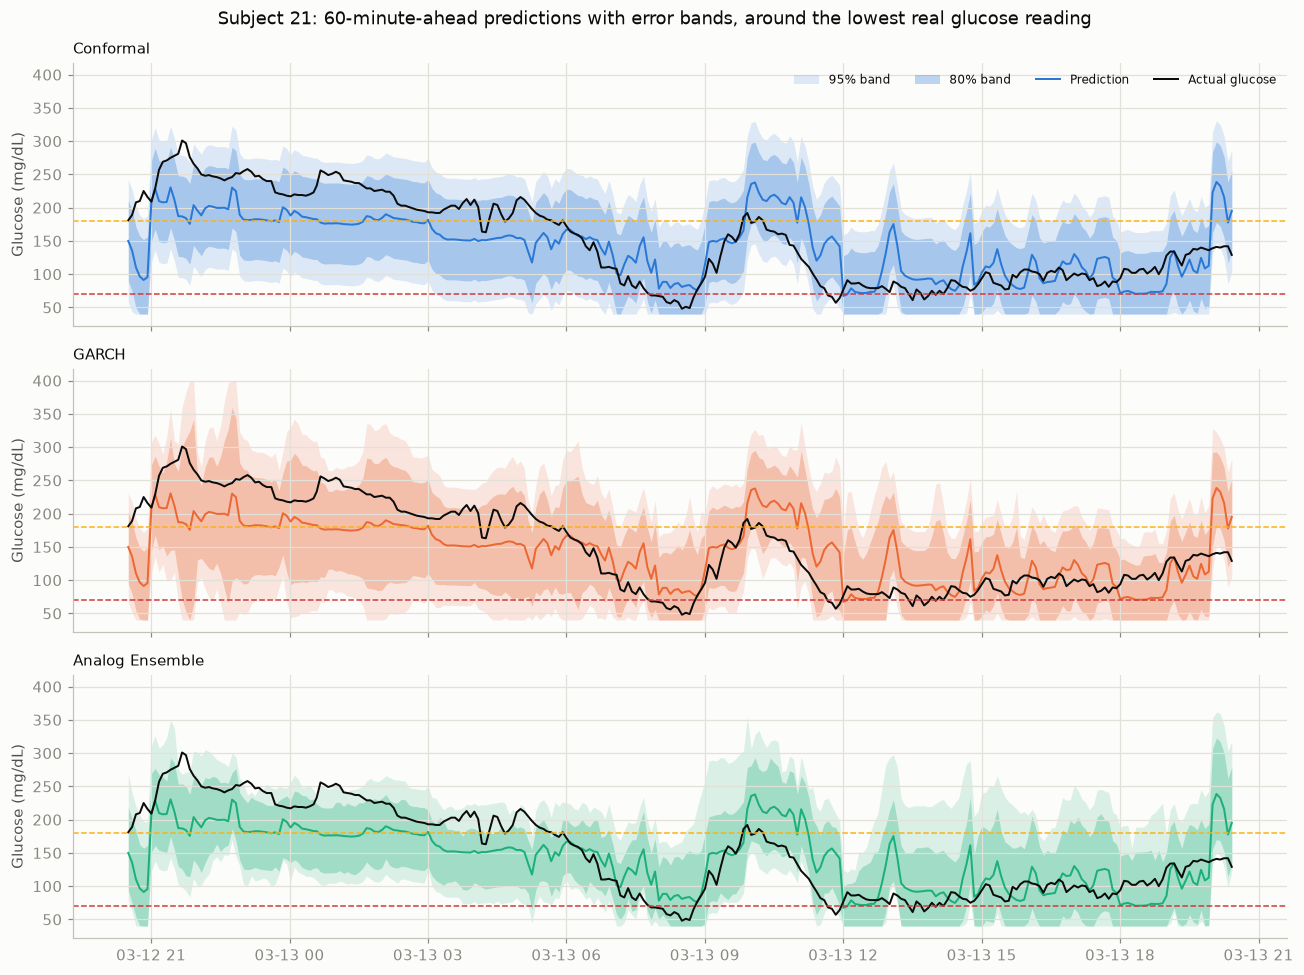

In [5]:
rmse = {sid: results[sid].rmse for sid in subject_ids}
best_sid, worst_sid = min(rmse, key=rmse.get), max(rmse, key=rmse.get)
show_sids = list(dict.fromkeys([1, best_sid, worst_sid]))
print(f"Subjects shown: 1 (usual example), {best_sid} (best, RMSE {rmse[best_sid]:.1f}), {worst_sid} (worst, RMSE {rmse[worst_sid]:.1f})")


def plot_bands(sid, half_window=144):
    val, test = frames[sid]
    center = int(np.argmin(test.actual))
    lo_i, hi_i = max(0, center - half_window), min(len(test.pred), center + half_window)
    x = pd.to_datetime(test.target_time[lo_i:hi_i])
    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True, sharey=True)
    for ax, method in zip(axes, METHODS):
        color = METHOD_COLOR[method]
        for level, alpha in ((0.95, 0.15), (0.8, 0.30)):
            lo, hi = bands[sid][method][level]
            ax.fill_between(x, lo[lo_i:hi_i], hi[lo_i:hi_i], color=color, alpha=alpha, linewidth=0,
                            label=f"{int(level * 100)}% band")
        ax.plot(x, test.pred[lo_i:hi_i], color=color, linewidth=1.3, label="Prediction")
        ax.plot(x, test.actual[lo_i:hi_i], color=plotting.INK_PRIMARY, linewidth=1.3, label="Actual glucose")
        ax.axhline(ref.HYPO_THRESHOLD, linestyle="--", color=plotting.GLUCOSE_BAND_COLORS["hypo"], linewidth=1)
        ax.axhline(ref.HYPER_THRESHOLD, linestyle="--", color=plotting.GLUCOSE_BAND_COLORS["hyper"], linewidth=1)
        ax.set_ylabel("Glucose (mg/dL)")
        ax.set_title(method, loc="left", fontsize=10)
    axes[0].legend(frameon=False, ncol=4, loc="upper right", fontsize=8)
    fig.suptitle(f"Subject {sid}: 60-minute-ahead predictions with error bands, around the lowest real glucose reading")
    fig.tight_layout()
    plt.show()


for sid in show_sids:
    plot_bands(sid)

The next figure shows how wide each band is over time for subject 1's whole test period (95% bands). Conformal is a flat line by construction. The interesting question is whether GARCH and the analog ensemble move in a way that means something.

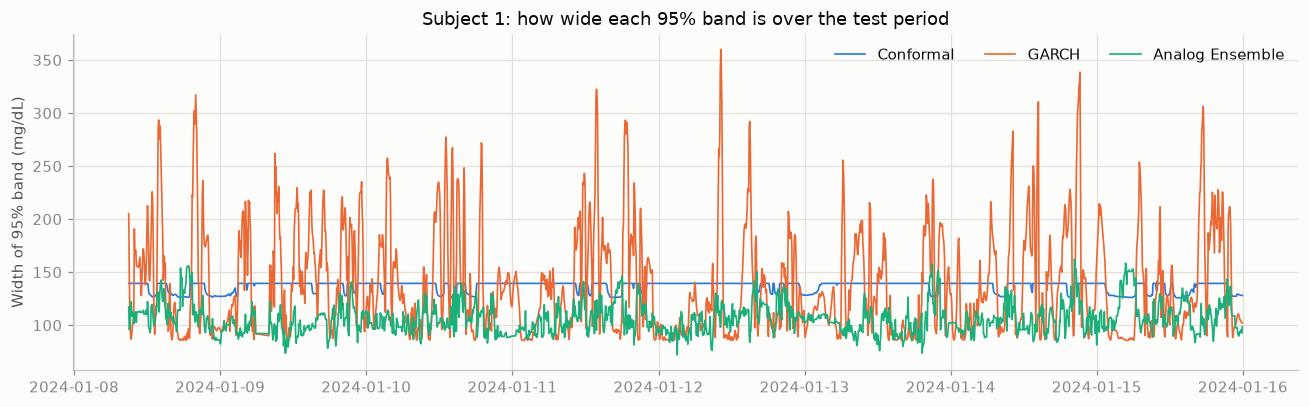

In [6]:
val, test = frames[1]
x = pd.to_datetime(test.target_time)
fig, ax = plt.subplots(figsize=(12, 3.8))
for method in METHODS:
    lo, hi = bands[1][method][0.95]
    ax.plot(x, hi - lo, color=METHOD_COLOR[method], linewidth=1.1, label=method)
ax.set_ylabel("Width of 95% band (mg/dL)")
ax.set_title("Subject 1: how wide each 95% band is over the test period")
ax.legend(frameon=False, ncol=3)
fig.tight_layout()
plt.show()

## 5. Do the bands actually contain the real glucose?

A 95% band that only contains the real value 80% of the time is not a 95% band. Below, "coverage" is the share of test predictions where the real glucose landed inside the band. All 25 patients are pooled (every prediction counts equally). The same is shown split by what the real glucose actually was, because a band that works in the normal range but fails during lows is not much use for safety.

"Interval score" combines width and misses into one number (lower is better): a narrow band that misses a lot is punished, and so is a wide band that is never wrong.

In [7]:
pooled = {}
for method in METHODS:
    for level in LEVELS:
        actual = np.concatenate([frames[s][1].actual for s in subject_ids])
        lo = np.concatenate([bands[s][method][level][0] for s in subject_ids])
        hi = np.concatenate([bands[s][method][level][1] for s in subject_ids])
        pooled[(method, level)] = (actual, lo, hi)

actual_all = np.concatenate([frames[s][1].actual for s in subject_ids])
pred_all = np.concatenate([frames[s][1].pred for s in subject_ids])
region_all = unc.region_of(actual_all)
print("Test windows by true glucose region:", {r: int((region_all == r).sum()) for r in ("hypo", "normal", "hyper")})

rows = []
for (method, level), (actual, lo, hi) in pooled.items():
    m = unc.interval_metrics(actual, lo, hi, level)
    per_patient = [unc.interval_metrics(frames[s][1].actual, *bands[s][method][level], level)["coverage"] for s in subject_ids]
    rows.append({
        "method": method, "band": f"{int(level * 100)}%", "coverage": m["coverage"],
        "coverage_hypo": m["coverage_hypo"], "coverage_normal": m["coverage_normal"], "coverage_hyper": m["coverage_hyper"],
        "mean_width": m["width"], "interval_score": m["interval_score"],
        "worst_patient_coverage": min(per_patient), "best_patient_coverage": max(per_patient),
    })
coverage_table = pd.DataFrame(rows).set_index(["band", "method"]).sort_index()
coverage_table.round(3)

Test windows by true glucose region: {'hypo': 963, 'normal': 47521, 'hyper': 11525}


coverage  coverage_hypo  coverage_normal  \
band method                                                      
80%  Analog Ensemble     0.739          0.521            0.766   
     Conformal           0.776          0.714            0.783   
     GARCH               0.784          0.746            0.791   
95%  Analog Ensemble     0.896          0.725            0.917   
     Conformal           0.942          0.855            0.956   
     GARCH               0.919          0.892            0.929   

                      coverage_hyper  mean_width  interval_score  \
band method                                                        
80%  Analog Ensemble           0.649      81.240         134.913   
     Conformal                 0.752      97.434         144.012   
     GARCH                     0.759     100.821         145.898   
95%  Analog Ensemble           0.824     123.203         200.825   
     Conformal                 0.891     149.182         194.892   
     GARCH                     0.882     147.716         213.646   

                      worst_patient_coverage  best_patient_coverage  
band method                                                          
80%  Analog Ensemble                   0.618                  0.858  
     Conformal                         0.681                  0.895  
     GARCH                             0.685                  0.857  
95%  Analog Ensemble                   0.781                  0.953  
     Conformal                         0.880                  0.975  
     GARCH                             0.857                  0.967

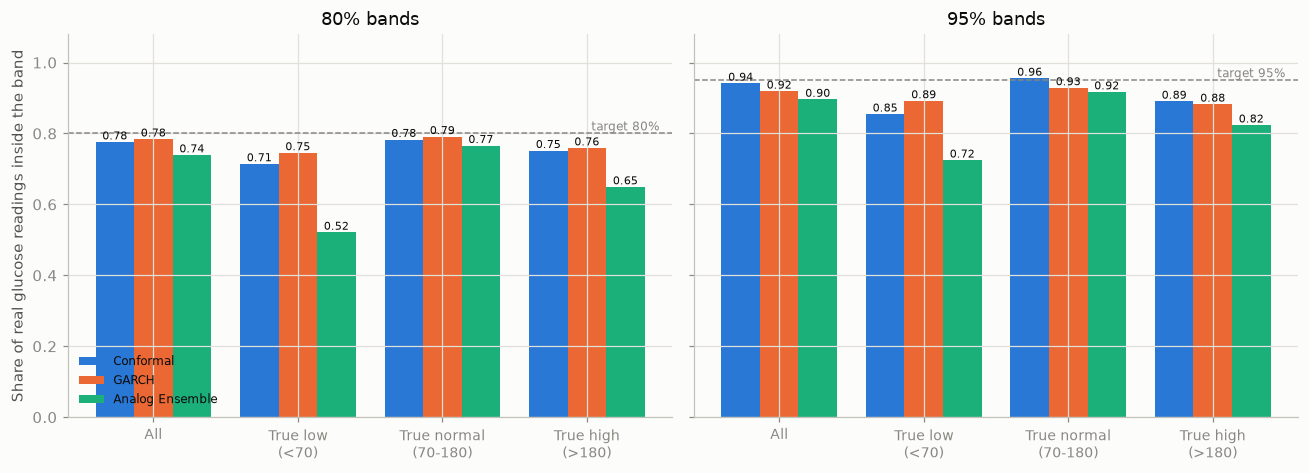

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
groups = ["coverage", "coverage_hypo", "coverage_normal", "coverage_hyper"]
labels = ["All", "True low\n(<70)", "True normal\n(70-180)", "True high\n(>180)"]
for ax, level in zip(axes, LEVELS):
    x = np.arange(len(groups))
    w = 0.8 / len(METHODS)
    for i, method in enumerate(METHODS):
        row = coverage_table.loc[(f"{int(level * 100)}%", method)]
        vals = [row[g] for g in groups]
        bars = ax.bar(x + (i - 1) * w, vals, w, color=METHOD_COLOR[method], label=method)
        for b, v in zip(bars, vals):
            ax.annotate(f"{v:.2f}", (b.get_x() + b.get_width() / 2, v), ha="center", va="bottom", fontsize=7)
    ax.axhline(level, linestyle="--", color=plotting.INK_MUTED, linewidth=1)
    ax.annotate(f"target {int(level * 100)}%", (len(groups) - 0.5, level), ha="right", va="bottom", fontsize=8, color=plotting.INK_MUTED)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylim(0, 1.08)
    ax.set_title(f"{int(level * 100)}% bands")
axes[0].set_ylabel("Share of real glucose readings inside the band")
axes[0].legend(frameon=False, loc="lower left", fontsize=8)
fig.tight_layout()
plt.show()

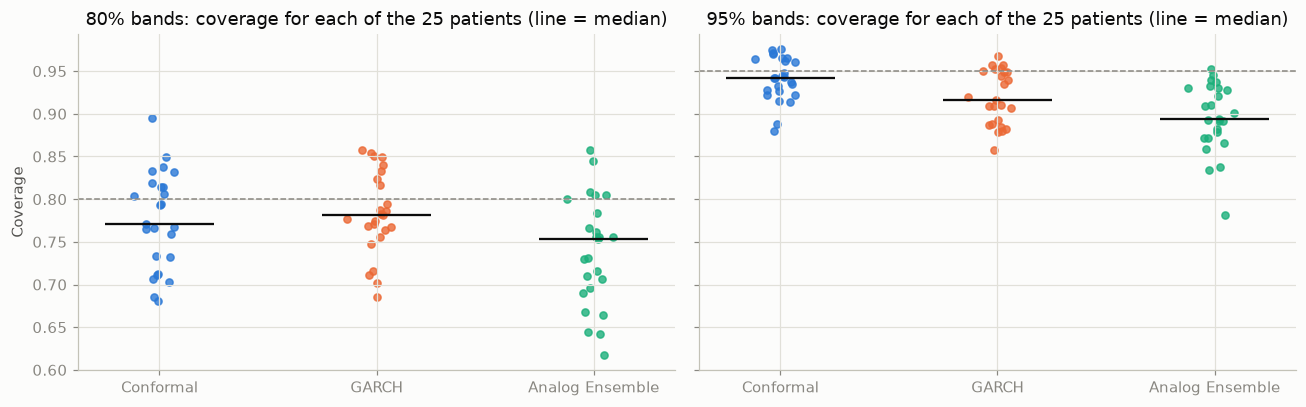

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, level in zip(axes, LEVELS):
    for i, method in enumerate(METHODS):
        vals = [unc.interval_metrics(frames[s][1].actual, *bands[s][method][level], level)["coverage"] for s in subject_ids]
        jitter = np.random.default_rng(i).normal(0, 0.05, len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals, color=METHOD_COLOR[method], s=22, alpha=0.8)
        ax.hlines(np.median(vals), i - 0.25, i + 0.25, color=plotting.INK_PRIMARY, linewidth=1.5)
    ax.axhline(level, linestyle="--", color=plotting.INK_MUTED, linewidth=1)
    ax.set_xticks(range(len(METHODS)))
    ax.set_xticklabels(METHODS)
    ax.set_title(f"{int(level * 100)}% bands: coverage for each of the 25 patients (line = median)")
axes[0].set_ylabel("Coverage")
fig.tight_layout()
plt.show()

## 6. Clarke Error Grid, part 1: grading the edges of the bands

The Clarke Error Grid grades a prediction by what a person would actually do differently because of the error: zone A is clinically fine, zone D means a real dangerous moment was predicted as safe. Here each band's **lower edge** and **upper edge** is graded as if it were a prediction against the real glucose. The lower edge answers "if I trusted the low end of the band, how bad could that be?", and the upper edge answers the same for the high end. The point forecast on its own is shown first for reference.

A well-behaved band should have a lower edge that is rarely an over-estimate of a real low, and an upper edge that is rarely an under-estimate of a real high.

How to read the tables and charts below: a wide band pushes its edges away from the real value by design, so plenty of edge predictions land outside zone A. That is not a flaw, it is what a band is. The rows that carry a safety meaning are zone D on the edge that is supposed to catch the danger (the lower edge for real lows, the upper edge for real highs). Section 7 turns that into a plainer measure. Note also that any band edge below 40 mg/dL is clipped to 40, the sensor floor, which is why so many lower-edge dots sit on a flat line at the bottom of the grid.

In [10]:
zone_rows = [{"what is graded": "Point forecast (no band)", "band": "-", **clarke_zone_percentages(actual_all, pred_all)}]
edge_pct = {}
for (method, level), (actual, lo, hi) in pooled.items():
    z = unc.band_edge_zones(actual, lo, hi)
    edge_pct[(method, level)] = z
    for edge in ("lower", "upper"):
        zone_rows.append({"what is graded": f"{method}, {edge} edge", "band": f"{int(level * 100)}%", **z[edge]})
edge_table = pd.DataFrame(zone_rows).set_index(["what is graded", "band"])
edge_table.round(2)

,,A,B,C,D,E
what is graded,band,,,,,
Point forecast (no band),-,51.50,46.70,0.25,1.33,0.21
"Conformal, lower edge",80%,35.55,59.50,0.68,3.42,0.85
"Conformal, upper edge",80%,22.33,66.63,9.21,1.49,0.33
"Conformal, lower edge",95%,13.90,77.92,1.80,4.09,2.28
"Conformal, upper edge",95%,10.43,61.31,26.51,1.17,0.58
"GARCH, lower edge",80%,30.65,62.50,1.25,3.14,2.46
"GARCH, upper edge",80%,28.90,59.20,10.06,1.34,0.49
"GARCH, lower edge",95%,14.71,73.75,3.09,2.60,5.85
"GARCH, upper edge",95%,14.90,59.27,24.04,0.97,0.81


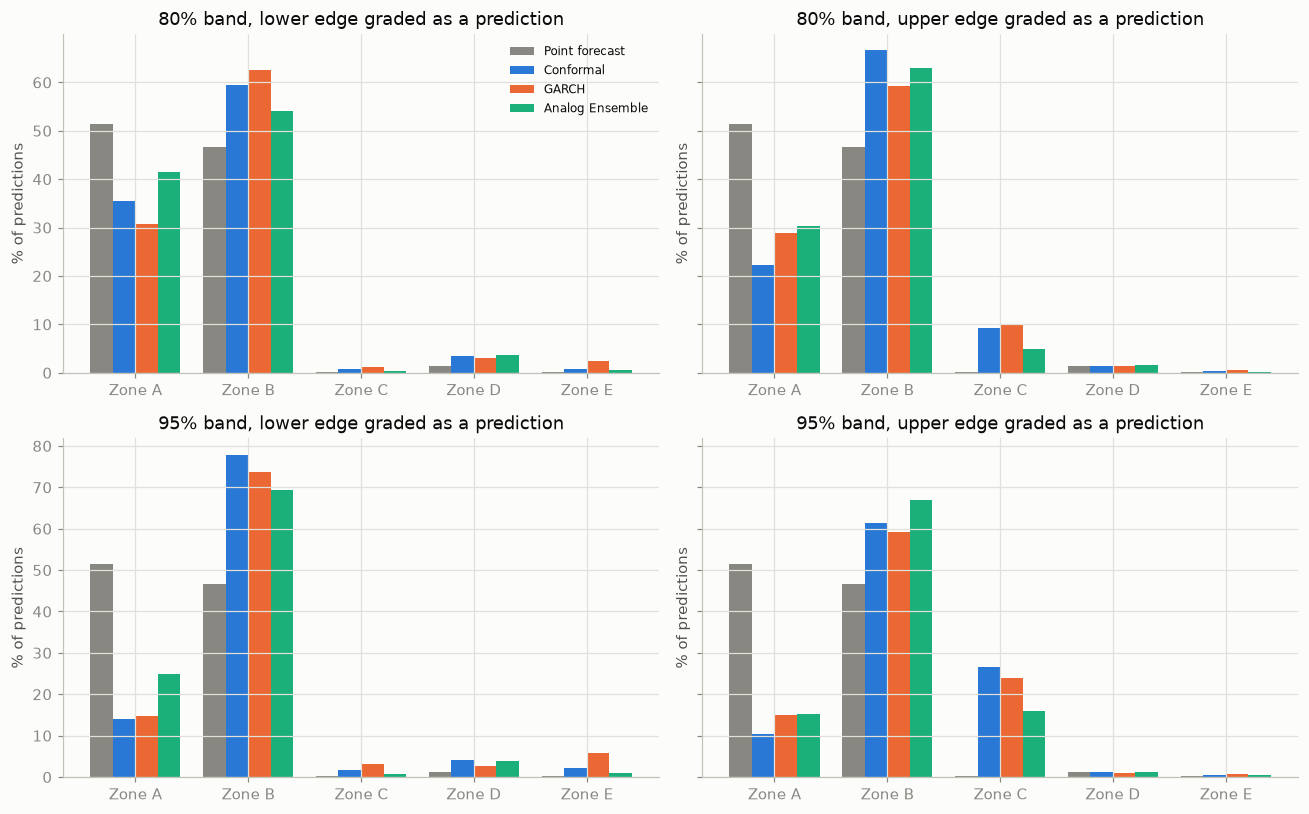

In [11]:
point = clarke_zone_percentages(actual_all, pred_all)
zones = ["A", "B", "C", "D", "E"]
fig, axes = plt.subplots(2, 2, figsize=(12, 7.5), sharey="row")
for r, level in enumerate(LEVELS):
    for c, edge in enumerate(("lower", "upper")):
        ax = axes[r, c]
        x = np.arange(len(zones))
        w = 0.8 / (len(METHODS) + 1)
        vals = [point[z] for z in zones]
        ax.bar(x - 1.5 * w, vals, w, color=plotting.INK_MUTED, label="Point forecast")
        for i, method in enumerate(METHODS):
            vals = [edge_pct[(method, level)][edge][z] for z in zones]
            ax.bar(x + (i - 0.5) * w, vals, w, color=METHOD_COLOR[method], label=method)
        ax.set_xticks(x)
        ax.set_xticklabels([f"Zone {z}" for z in zones])
        ax.set_title(f"{int(level * 100)}% band, {edge} edge graded as a prediction")
        ax.set_ylabel("% of predictions")
axes[0, 0].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

The grid itself, for the 95% bands, with a random 6,000 predictions per panel. Each dot is one prediction (a band edge) plotted against the real glucose; dots on the dotted diagonal would be perfect. The black lines are the zone boundaries.

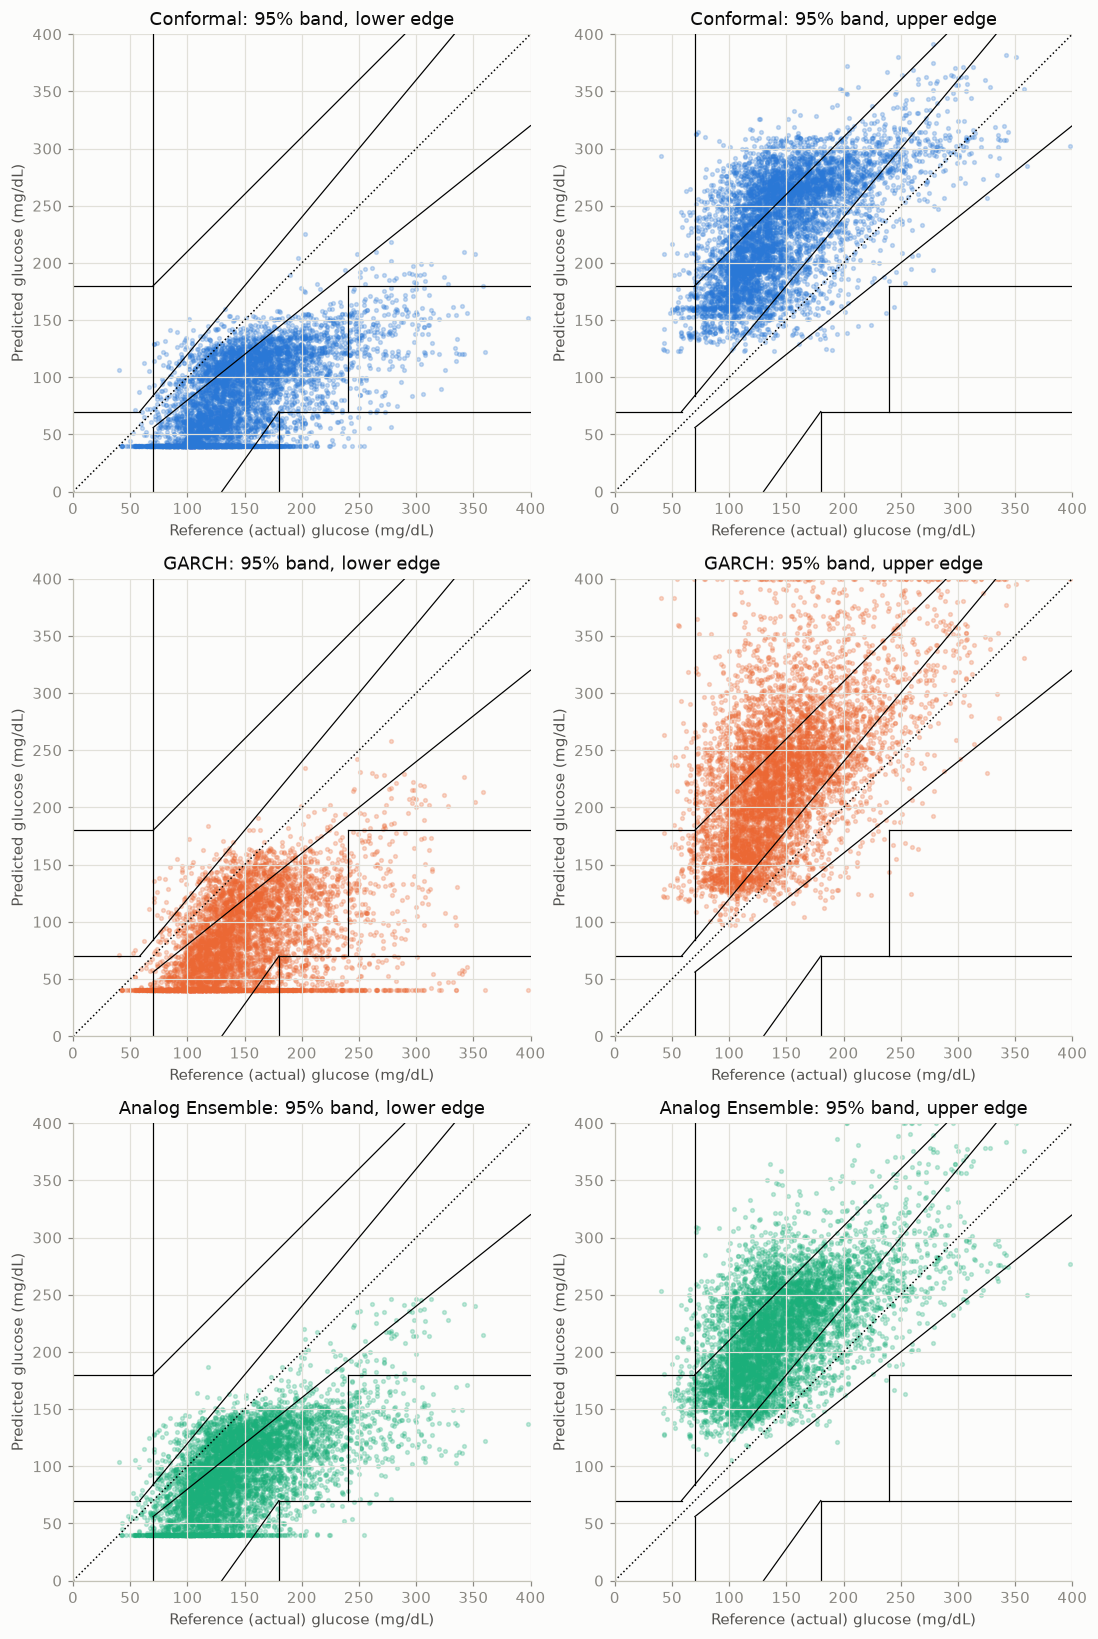

In [12]:
rng = np.random.default_rng(0)
sample = rng.choice(len(actual_all), 6000, replace=False)
fig, axes = plt.subplots(3, 2, figsize=(10, 15))
for r, method in enumerate(METHODS):
    actual, lo, hi = pooled[(method, 0.95)]
    for c, (edge, vals) in enumerate((("Lower", lo), ("Upper", hi))):
        ax = axes[r, c]
        draw_clarke_grid(ax, actual[sample], vals[sample], METHOD_COLOR[method])
        ax.set_title(f"{method}: 95% band, {edge.lower()} edge")
fig.tight_layout()
plt.show()

## 7. Clarke Error Grid, part 2: does a wide band warn you about a dangerous miss?

The other way to use uncertainty is as a warning light. If the model is about to be clinically wrong (Clarke zone C, D, or E), does its band get wider beforehand? Below, the point forecast is graded on the Clarke grid as usual, and the average band width is compared across zones.

The **warning score** puts that in one number: the chance that a randomly picked clinically bad forecast (zone C, D, or E) has a wider band than a randomly picked fine one (zone A or B). 0.5 means the band width tells you nothing, and 1.0 means wider bands perfectly flag the bad forecasts. Conformal is a constant width, so it should sit at 0.5. It lands a little off that only because bands get clipped at the sensor limits (40 and 400 mg/dL), which shortens some of them. It is the do-nothing reference.

In [13]:
point_zone = clarke_error_grid_zones(actual_all, pred_all)
print("Point-forecast windows by Clarke zone:", {z: int((point_zone == z).sum()) for z in "ABCDE"})

width_rows, auc_rows = [], []
for method in METHODS:
    for level in LEVELS:
        actual, lo, hi = pooled[(method, level)]
        width = hi - lo
        width_rows.append({"method": method, "band": f"{int(level * 100)}%", **unc.width_by_point_zone(actual_all, pred_all, width)})
        per_patient = [unc.width_warning_auc(frames[s][1].actual, frames[s][1].pred, bands[s][method][level][1] - bands[s][method][level][0]) for s in subject_ids]
        auc_rows.append({
            "method": method, "band": f"{int(level * 100)}%",
            "warning_score_pooled": unc.width_warning_auc(actual_all, pred_all, width),
            "warning_score_median_patient": float(np.nanmedian(per_patient)),
        })
print("\nMean band width (mg/dL) by Clarke zone of the point forecast:")
display(pd.DataFrame(width_rows).set_index(["band", "method"]).sort_index().round(1))
print("Warning score (0.5 = no information, 1.0 = perfect):")
display(pd.DataFrame(auc_rows).set_index(["band", "method"]).sort_index().round(3))

Point-forecast windows by Clarke zone: {'A': 30903, 'B': 28027, 'C': 153, 'D': 800, 'E': 126}

Mean band width (mg/dL) by Clarke zone of the point forecast:


A      B      C      D      E
band method                                            
80%  Analog Ensemble   79.2   83.2   92.6   85.7   86.7
     Conformal         96.8   98.0  101.2  100.1   88.8
     GARCH             98.2  103.1  112.9  118.1  110.9
95%  Analog Ensemble  121.9  124.5  137.4  128.1  125.4
     Conformal        150.0  148.4  158.2  148.3  130.0
     GARCH            144.5  150.6  164.6  165.0  159.1

Warning score (0.5 = no information, 1.0 = perfect):


warning_score_pooled  warning_score_median_patient
band method                                                             
80%  Analog Ensemble                 0.579                         0.579
     Conformal                       0.514                         0.500
     GARCH                           0.581                         0.542
95%  Analog Ensemble                 0.566                         0.514
     Conformal                       0.467                         0.428
     GARCH                           0.564                         0.526

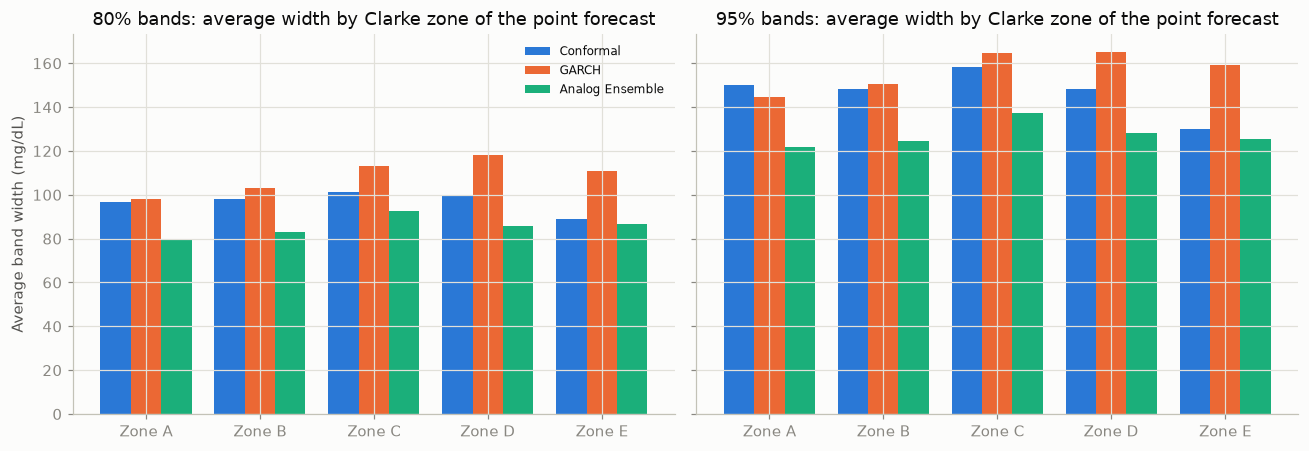

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, level in zip(axes, LEVELS):
    x = np.arange(5)
    w = 0.8 / len(METHODS)
    for i, method in enumerate(METHODS):
        row = next(r for r in width_rows if r["method"] == method and r["band"] == f"{int(level * 100)}%")
        vals = [row[z] for z in "ABCDE"]
        ax.bar(x + (i - 1) * w, vals, w, color=METHOD_COLOR[method], label=method)
    ax.set_xticks(x)
    ax.set_xticklabels([f"Zone {z}" for z in "ABCDE"])
    ax.set_title(f"{int(level * 100)}% bands: average width by Clarke zone of the point forecast")
axes[0].set_ylabel("Average band width (mg/dL)")
axes[0].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

## 8. Does the band catch dangerous moments the point forecast misses?

This is the safety reading of the band edges. Treat the **lower edge** as a low-glucose alarm (it fires when the edge drops below 70 mg/dL) and the **upper edge** as a high-glucose alarm (it fires when the edge goes above 180 mg/dL). "Caught" is the share of real lows (or real highs) the alarm fired for. "False alarms" is the share of the other readings it fired for anyway. The point forecast row is the same idea with the prediction itself as the alarm, and is what stage 1's recall numbers measured.

A band earns its keep if it catches clearly more real danger than the point forecast without an unusable number of false alarms.

In [15]:
def alarm_rates(actual, low_signal, high_signal):
    hypo = actual < ref.HYPO_THRESHOLD
    hyper = actual > ref.HYPER_THRESHOLD
    return {
        "real lows caught": float((low_signal[hypo] < ref.HYPO_THRESHOLD).mean()),
        "false low alarms": float((low_signal[~hypo] < ref.HYPO_THRESHOLD).mean()),
        "real highs caught": float((high_signal[hyper] > ref.HYPER_THRESHOLD).mean()),
        "false high alarms": float((high_signal[~hyper] > ref.HYPER_THRESHOLD).mean()),
    }

alarm_rows = [{"alarm source": "Point forecast", "band": "-", **alarm_rates(actual_all, pred_all, pred_all)}]
for (method, level), (actual, lo, hi) in pooled.items():
    alarm_rows.append({"alarm source": method, "band": f"{int(level * 100)}%", **alarm_rates(actual, lo, hi)})
alarm_table = pd.DataFrame(alarm_rows).set_index(["alarm source", "band"])
alarm_table.round(3)

real lows caught  false low alarms  real highs caught  \
alarm source    band                                                          
Point forecast  -                0.403             0.042              0.738   
Conformal       80%              0.760             0.229              0.936   
                95%              0.885             0.442              0.972   
GARCH           80%              0.825             0.297              0.915   
                95%              0.919             0.496              0.956   
Analog Ensemble 80%              0.664             0.157              0.909   
                95%              0.793             0.267              0.969   

                      false high alarms  
alarm source    band                     
Point forecast  -                 0.265  
Conformal       80%               0.589  
                95%               0.793  
GARCH           80%               0.534  
                95%               0.684  
Analog Ensemble 80%               0.490  
                95%               0.718

## 9. Summary table

One row per method and band size, pulling the headline numbers together.

In [16]:
summary = coverage_table[["coverage", "coverage_hypo", "mean_width", "interval_score"]].copy()
summary["lower_edge_zone_D_pct"] = [edge_pct[(m, float(b.strip("%")) / 100)]["lower"]["D"] for b, m in summary.index]
summary["upper_edge_zone_D_pct"] = [edge_pct[(m, float(b.strip("%")) / 100)]["upper"]["D"] for b, m in summary.index]
warning = pd.DataFrame(auc_rows).set_index(["band", "method"])["warning_score_pooled"]
summary["warning_score"] = warning
summary.round(3)

coverage  coverage_hypo  mean_width  interval_score  \
band method                                                                 
80%  Analog Ensemble     0.739          0.521      81.240         134.913   
     Conformal           0.776          0.714      97.434         144.012   
     GARCH               0.784          0.746     100.821         145.898   
95%  Analog Ensemble     0.896          0.725     123.203         200.825   
     Conformal           0.942          0.855     149.182         194.892   
     GARCH               0.919          0.892     147.716         213.646   

                      lower_edge_zone_D_pct  upper_edge_zone_D_pct  \
band method                                                          
80%  Analog Ensemble                  3.621                  1.581   
     Conformal                        3.419                  1.493   
     GARCH                            3.140                  1.340   
95%  Analog Ensemble                  3.819                  1.176   
     Conformal                        4.094                  1.168   
     GARCH                            2.598                  0.972   

                      warning_score  
band method                          
80%  Analog Ensemble          0.579  
     Conformal                0.514  
     GARCH                    0.581  
95%  Analog Ensemble          0.566  
     Conformal                0.467  
     GARCH                    0.564

## 10. What this shows

All numbers below pool the 25 patients' test periods (about 60,000 predictions, of which only 963 are true lows and 11,525 are true highs). Nothing was fitted on the test period. This covers one model (the fixed-weight CNN-LSTM) on one dataset (AZT1D), so treat it as a first look rather than a final answer.

**None of the three methods delivers the coverage it promises, and they fall shortest exactly where it matters.** Overall, basic conformal is the best calibrated: its 80% band contains the real glucose 77.6% of the time and its 95% band 94.2%. GARCH is at 78.4% and 91.9%, and the analog ensemble is furthest off at 73.9% and 89.6%. But split by what glucose actually did, every method under-covers the dangerous moments. For real lows, a 95% band contains the truth 85% of the time for conformal, 89% for GARCH, and only 72% for the analog ensemble. For real highs it is 89%, 88%, and 82%. The bands are sized on the model's typical error, and the model is wrong by more than that at the extremes. Patients also differ a lot: conformal's 80% band covers between 68% and 90% depending on the patient.

**Which band is "best" depends on what you measure.** On the interval score, which rewards narrow bands that are rarely wrong, the analog ensemble wins at 80% (134.9 against 144.0 for conformal and 145.9 for GARCH) because its bands are the narrowest, and conformal wins at 95% (194.9 against 200.8 and 213.6). GARCH is never the best on that score. Its bands swing wildly, from about 90 mg/dL wide to over 350 within the same day for subject 1, while conformal stays flat at about 140. Those swings are not pure noise: GARCH is the method whose bands are widest around clinically bad forecasts (at 80%, an average width of 118 mg/dL when the forecast lands in Clarke zone D, against 98 in zone A). But the signal is weak. The warning score, which is 0.5 for a band that tells you nothing, is only 0.56 to 0.58 for GARCH and the analog ensemble, and about 0.5 for conformal. A wider band is a slight hint that the forecast may be clinically wrong, not a reliable warning light.

**On the Clarke Error Grid, a wide band is not automatically a safe one.** Graded as if it were a prediction, a band's edges land outside zone A a lot, which is what a band is. The useful comparisons are elsewhere. The upper edge lands in zone C (a prediction more than 110 mg/dL above the truth) 16% to 27% of the time at 95%, which is the cost of a wide top edge. GARCH's 95% lower edge lands in zone E (the worst case, predicting a low when glucose is really high) 5.9% of the time, against 2.3% for conformal and 1.1% for the analog ensemble, because its widest bands stretch furthest. For the point forecast alone, the dangerous miss (zone D) happens 1.3% of the time.

**The clearest practical result is the alarm test.** Used as an alarm (low edge under 70, high edge over 180), the point forecast catches only 40% of real lows, with 4% false alarms. Every band catches far more: 66% of real lows for the analog ensemble at 80%, 76% for conformal, 83% for GARCH, up to 92% at 95%. The price is false alarms, from 16% (analog, 80%) up to 50% (GARCH, 95%). The three methods sit on roughly the same trade-off curve, so none clearly dominates. For highs the bands are much less useful: they catch 91% to 97% of real highs but fire falsely on 49% to 79% of everything else, against 27% for the point forecast. So the uncertainty adds real safety information for lows, and very little for highs.

**Caveats.** The bands are calibrated on each patient's validation period and judged on a later test period, so any drift between them shows up as missed coverage. Consecutive predictions overlap heavily, which breaks the exchangeability assumption conformal is built on, so its guarantee does not strictly apply here. The analog ensemble's settings (50 analogs, spacing, time-of-day weight) were not tuned. And there are few true lows per patient, so the low-glucose numbers are the least certain.

**Next step this points to.** Because every band under-covers the danger zones, the obvious follow-up is a band that is calibrated separately by predicted glucose region (for example conformal calibrated only on the model's errors near lows), rather than one band size for everything.